In [1]:
import numpy as np
import pandas as pd
from zipfile import ZipFile
import os

In [2]:
# 압축푼 csv파일을 넣어둘 디렉토리 생성
!mkdir data

In [3]:
# 각자 instacart-market-basket-analysis 폴더 경로 변수 지정
path = '/content/drive/MyDrive/해커톤/instacart-market-basket-analysis'

In [4]:
# 해당 경로에 있는 zip파일 모두 리스트로 반환
zipfiles = [ file for file in os.listdir(path) if file.endswith('zip')] 
print(zipfiles)

['aisles.csv.zip', 'departments.csv.zip', 'order_products__prior.csv.zip', 'orders.csv.zip', 'order_products__train.csv.zip', 'products.csv.zip', 'sample_submission.csv.zip']


In [5]:
# 위에서 생성한 data 폴더안에 csv파일 압축해제
for zipfile in zipfiles:
    file_name = path + '/' + zipfile
    csv_file = zipfile[:-4]

    with ZipFile(file_name, 'r') as zip:
        zip.extract(csv_file, 'data')

In [6]:
aisles = pd.read_csv('/content/data/aisles.csv')
departments = pd.read_csv('/content/data/departments.csv')
order_products_prior = pd.read_csv('/content/data/order_products__prior.csv')
order_products_train = pd.read_csv('/content/data/order_products__train.csv')
orders = pd.read_csv('/content/data/orders.csv')
products = pd.read_csv('/content/data/products.csv')
products = pd.read_csv('/content/data/sample_submission.csv')

# Simple Exploration Notebook - Instacart

In this notebook, we will try and explore the basic information about the dataset given. The dataset for this competition is a relational set of files describing customers' orders over time.

### Objective:

The goal of the competition is to predict which products will be in a user's next order. The dataset is anonymized and contains a sample of over 3 million grocery orders from more than 200,000 Instacart users. 

For each user, 4 and 100 of their orders are given, with the sequence of products purchased in each order.

Let us start by importing the necessary modules.

In [7]:
import matplotlib.pyplot as plt 
import seaborn as sns
color = sns.color_palette()

%matplotlib inline

pd.options.mode.chained_assignment = None # default='warn'

Let us list out the files that are present in this competition.!

In [ ]:
from subprocess import check_output
print(check_output(['ls', '/content/data']).decode('utf8'))

aisles.csv
departments.csv
order_products__prior.csv
order_products__train.csv
orders.csv
products.csv
sample_submission.csv



Before we dive deep into the exploratory analysis, let us know a little more about the files given. To understand it better, let us first read all the files as dataframe objects and then look at the top few rows.

In [ ]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [ ]:
order_products_prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [ ]:
order_products_train.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


As we could see, orders.csv has all the information about the given order id like the user who has purchased the order, when was it purchased, days since prior order and so on.

The columns present in order_products_train and order_products_prior are same. Then what is the difference between these files?

As mentioned earlier, in this dataset, 4 to 100 orders of a customer are given (we will look at this later) and we need to predict the products that will be re-ordered. So the last order of the user has been taken out and divided into train and test sets. All the prior order informations of the customer are present in order_products_prior file. We can also note that there is a column in orders.csv file called eval_set which tells us as to which of the three datasets (prior, train or test) the given row goes to. 

Order_products*csv file has more detalied information about the products that been bought in the given order along with the re-orderd status. 

Let us first get the count of rows in each of the three sets.

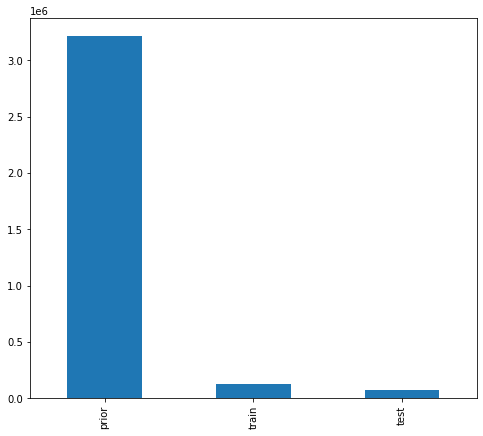

In [ ]:
plt.figure(figsize=(8, 7))
orders['eval_set'].value_counts().plot.bar()
plt.show()

In [ ]:
# 필사 버전
def get_unique_count(x):
    return len(np.unique(x))

orders.groupby('eval_set')['user_id'].aggregate(get_unique_count)

# 같은 결과
orders.groupby('eval_set')['user_id'].nunique()

eval_set
prior    206209
test      75000
train    131209
Name: user_id, dtype: int64

So there are 206,209 customers in total. Out of which, the last purchase of 131,209 customers are given as train set and we need to predict for the rest 75,000 customers. 

Now let us validate the claim that 4 to 100 orders of a customer are given.

In [ ]:
orders.groupby('user_id')['order_number'].max().describe()

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_number, dtype: float64

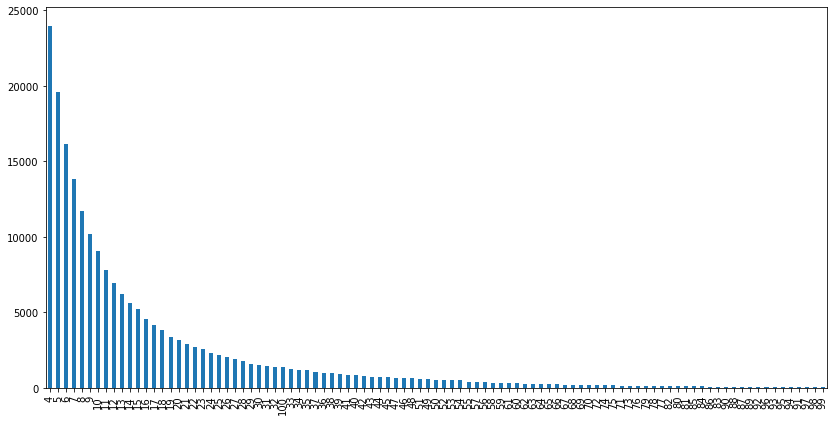

In [ ]:
plt.figure(figsize=(14, 7))
orders.groupby('user_id')['order_number'].max().value_counts().plot.bar()
plt.show()

So there are no orders less than 4 and is max capped at 100 as given in the data page. 

Now let us see how the ordering habit changes with day of week.

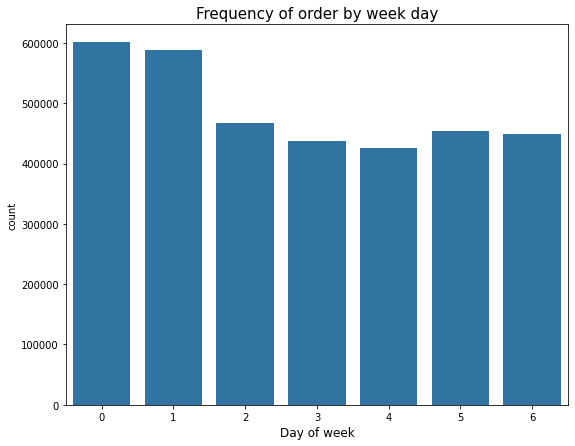

In [ ]:
plt.figure(figsize=(9, 7))
sns.countplot(x='order_dow', data=orders, color=color[0])
plt.title("Frequency of order by week day", fontsize=15)
plt.xlabel('Day of week', fontsize=12)
plt.show()

Seems like 0 and 1 are Saturday and Sunday when the orders are high and low during Wednesday. 

Now we shall see how the distribution is with respect to time of the day.

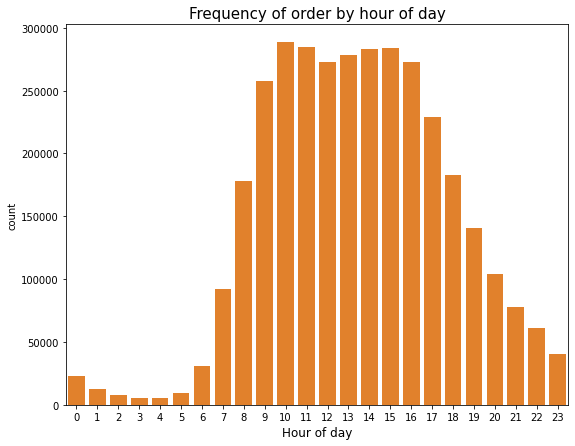

In [ ]:
plt.figure(figsize=(9, 7))
sns.countplot(x='order_hour_of_day', data=orders, color=color[1])
plt.title("Frequency of order by hour of day", fontsize=15)
plt.xlabel('Hour of day', fontsize=12)
plt.show()

So majority of the orders are made during day time. Now let us combine the day of week and hour of day to see the distribution.

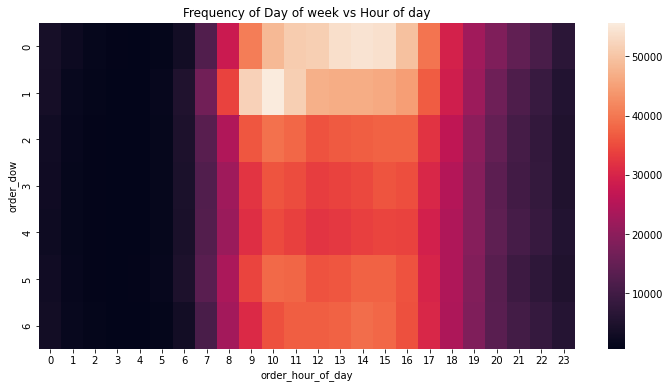

In [ ]:
grouped_df = orders.groupby(['order_dow', 'order_hour_of_day'])['order_number'].count().reset_index()
grouped_df = grouped_df.pivot('order_dow', 'order_hour_of_day', 'order_number')
plt.figure(figsize=(12, 6))
sns.heatmap(grouped_df)
plt.title('Frequency of Day of week vs Hour of day')
plt.show()

Seems Saturday evenings and Sunday mornings are the prime for orders.

Now let us check the time interval between the orders.



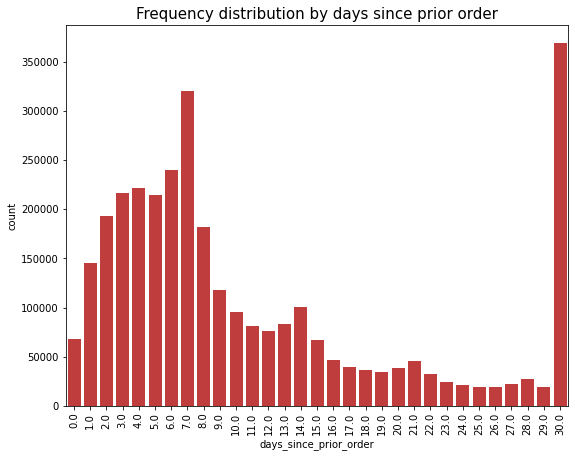

In [ ]:
plt.figure(figsize=(9,7))
sns.countplot(x='days_since_prior_order', data=orders, color=color[3])
plt.xticks(rotation='vertical')
plt.title("Frequency distribution by days since prior order", fontsize=15)
plt.show()

In [ ]:
orders.isnull().sum()

order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

Looks like customers order once in every week (check the peak at 7 days) or once in a month (peak at 30 days). We could also see smaller peaks at 14, 21 and 28 days (weekly intervals).

Since our objective is to figure out the re-orders, let us check out the re-order percentage in prior set and train set.

In [9]:
order_products_prior.head(10)

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0
5,2,17794,6,1
6,2,40141,7,1
7,2,1819,8,1
8,2,43668,9,0
9,3,33754,1,1


In [10]:
# percentage of re-orders in prior set
order_products_prior['reordered'].sum() / order_products_prior.shape[0]

0.5896974667922161

In [11]:
# percentage of re-orders in train set
order_products_train['reordered'].sum() / order_products_train.shape[0]

0.5985944127509629

On an average, about 59% of the products in an order are re-ordered products. 

**No re-ordered products:**

Now that we have seen 59% of the products are re-ordered, there will also be situations when none of the products are re-ordered. Let us check that now.



In [29]:
grouped_df = order_products_prior.groupby('order_id')['reordered'].sum().reset_index()
grouped_df.head()

,order_id,reordered
0,2,6
1,3,8
2,4,12
3,5,21
4,6,0


In [30]:
grouped_df[grouped_df['reordered'] > 1] = 1
grouped_df['reordered'].value_counts() / grouped_df.shape[0]

1    0.879151
0    0.120849
Name: reordered, dtype: float64

In [31]:
grouped_df = order_products_train.groupby('order_id')['reordered'].sum().reset_index()
grouped_df[grouped_df['reordered'] > 1] = 1
grouped_df['reordered'].value_counts() / grouped_df.shape[0]

1    0.93444
0    0.06556
Name: reordered, dtype: float64

About 12% of the orders in prior set has no re-ordered items while in the train set it is 6.5%.

Now let us see the number of products bought in each order.

더 많은 데이터가 있는 prior셋에서 좀 더 일반적인 평균 수치일 가능성이 높아보인다. 검증하기 위해서는 prior셋에서 가장 마지막 order를 뽑아서 평균을 내본다.

orders에서 각 user_id 마다 가장 큰 order_number-1의 order_id를 추출하면 된다.

In [49]:
a = orders.groupby('user_id')['order_number'].max()-1
# orders[orders['order_number'] == a]['order_id']
a

user_id
1         10
2         14
3         12
4          5
5          4
          ..
206205     3
206206    67
206207    16
206208    49
206209    13
Name: order_number, Length: 206209, dtype: int64

In [36]:
orders.head(40)

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0
5,3367565,1,prior,6,2,7,19.0
6,550135,1,prior,7,1,9,20.0
7,3108588,1,prior,8,1,14,14.0
8,2295261,1,prior,9,1,16,0.0
9,2550362,1,prior,10,4,8,30.0
